# Proyecto Tutorial de Clasficador de Imagenes

# Paso 1: Carga del conjunto de datos

In [67]:
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Dropout, GlobalAveragePooling2D, Flatten
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [68]:
import zipfile
import os

zip_path = '/content/train.zip'
extract_path = '/content/'

if os.path.exists(zip_path):
    print("Descomprimiendo archivo... Esto puede tardar un momento debido al volumen de imágenes.")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("¡Descompresión completada!")
else:
    print("ERROR: No se encontró train.zip en /content/")

Descomprimiendo archivo... Esto puede tardar un momento debido al volumen de imágenes.
¡Descompresión completada!


In [69]:
from pathlib import Path

# Definimos la ruta local donde se descomprimieron las fotos
train_dir = Path("/content/train")

# Verificación de contenido
if train_dir.exists():
    image_files = list(train_dir.glob("*.jpg"))
    print(f"Carpeta encontrada en: {train_dir}")
    print("Cantidad total de imágenes detectadas:", len(image_files))
else:
    # A veces el zip crea una subcarpeta extra, verificamos eso
    print(f"ERROR: No se encontró la carpeta en {train_dir}.")
    # Listar directorios para ayudar al usuario a debuguear
    print("Directorios disponibles en /content/:", [d for d in os.listdir('/content/') if os.path.isdir(os.path.join('/content/', d))])

Carpeta encontrada en: /content/train
Cantidad total de imágenes detectadas: 25000


In [70]:
df = pd.DataFrame({
    "filepath": [str(p) for p in image_files],
    "label": [1 if p.name.startswith("dog") else 0 for p in image_files]
})

print(df.head())
print("\nDimensión del dataset:", df.shape)
print("\nDistribución de clases:")
print(df["label"].value_counts())

                       filepath  label
0  /content/train/dog.10324.jpg      1
1  /content/train/cat.10024.jpg      0
2   /content/train/cat.6369.jpg      0
3   /content/train/cat.1920.jpg      0
4  /content/train/cat.11797.jpg      0

Dimensión del dataset: (25000, 2)

Distribución de clases:
label
1    12500
0    12500
Name: count, dtype: int64


### Asignamos:
- cat = 0
- dog = 1

# Paso 2: Visualiza la información de entrada

In [71]:
dog_files = sorted(train_dir.glob("dog.*.jpg"))
cat_files = sorted(train_dir.glob("cat.*.jpg"))

print("Cantidad de perros:", len(dog_files))
print("Cantidad de gatos:", len(cat_files))

Cantidad de perros: 12500
Cantidad de gatos: 12500


## Visualizamos 9 perros

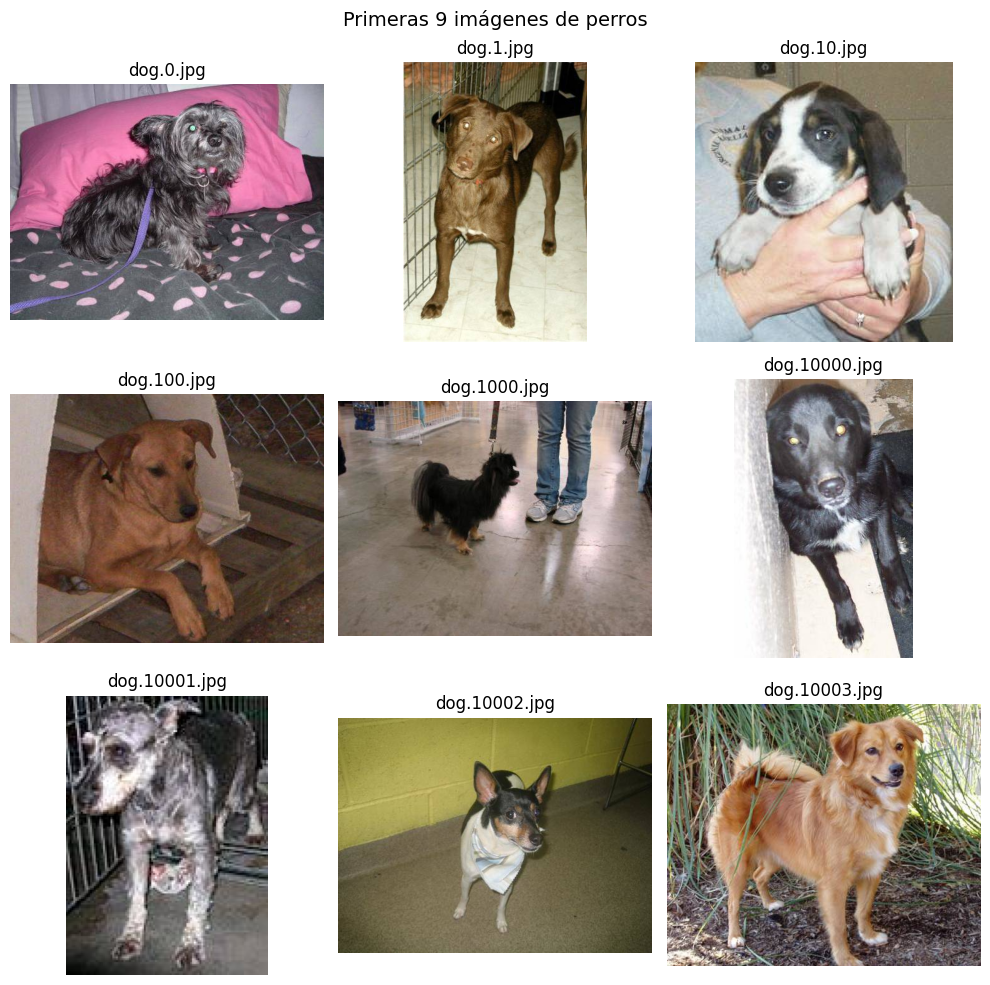

In [72]:
plt.figure(figsize=(10, 10))

for i, img_path in enumerate(dog_files[:9]):
    img = Image.open(img_path)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(img_path.name)
    plt.axis("off")

plt.suptitle("Primeras 9 imágenes de perros", fontsize=14)
plt.tight_layout()
plt.show()

## Visualizamos 9 gatos

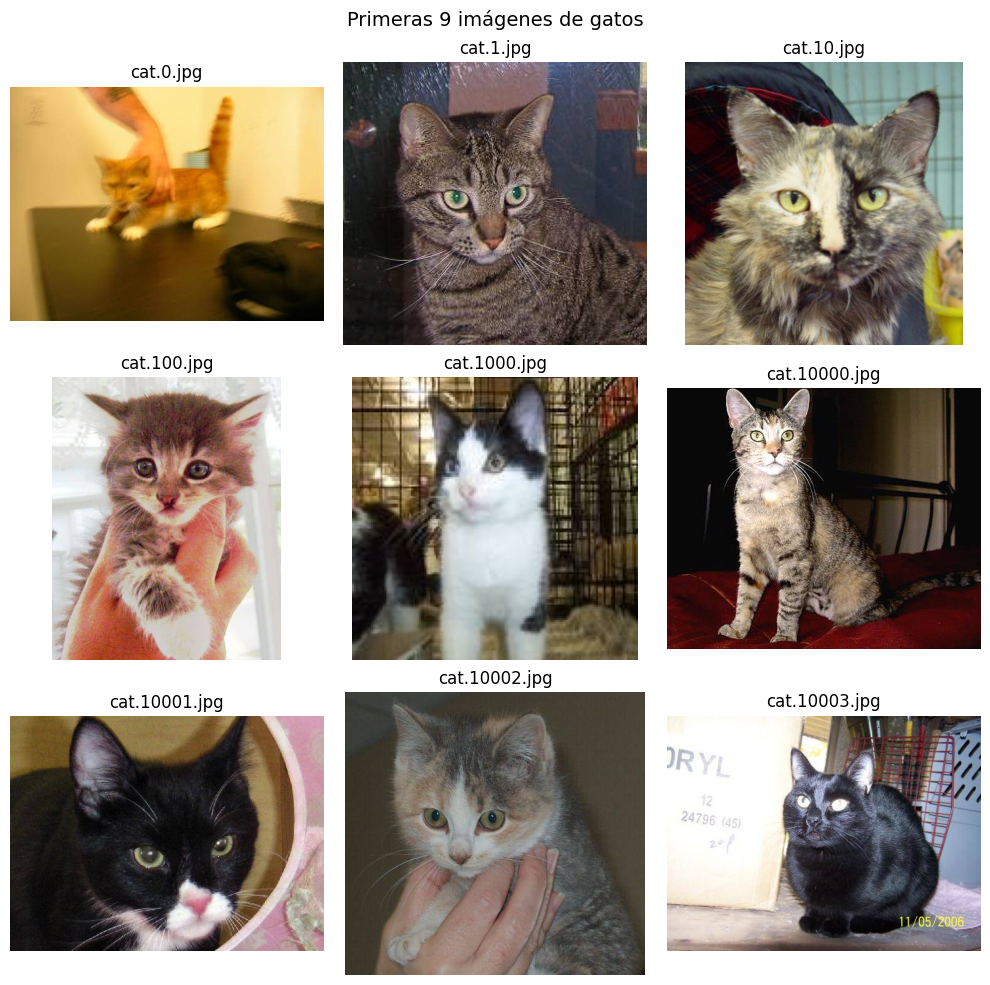

In [73]:
plt.figure(figsize=(10, 10))

for i, img_path in enumerate(cat_files[:9]):
    img = Image.open(img_path)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(img_path.name)
    plt.axis("off")

plt.suptitle("Primeras 9 imágenes de gatos", fontsize=14)
plt.tight_layout()
plt.show()

### Visualizamos las dimensiones de algunas imagenes

In [74]:
for img_path in dog_files[:5]:
    img = Image.open(img_path)
    print(f"{img_path.name} -> tamaño: {img.size}")

for img_path in cat_files[:5]:
    img = Image.open(img_path)
    print(f"{img_path.name} -> tamaño: {img.size}")

dog.0.jpg -> tamaño: (499, 375)
dog.1.jpg -> tamaño: (327, 499)
dog.10.jpg -> tamaño: (269, 292)
dog.100.jpg -> tamaño: (500, 397)
dog.1000.jpg -> tamaño: (499, 375)
cat.0.jpg -> tamaño: (500, 374)
cat.1.jpg -> tamaño: (300, 280)
cat.10.jpg -> tamaño: (489, 499)
cat.100.jpg -> tamaño: (403, 499)
cat.1000.jpg -> tamaño: (150, 149)


## Redimensionamos las imagenes a un formato de 200x200

In [75]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Train shape: (20000, 2)
Test shape : (5000, 2)


### Definir parámetros del pipeline

In [76]:
IMG_SIZE = (200, 200)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

- Todas las imágenes pasarán a 200x200
- Se procesarán en lotes de 32
- TensorFlow optimizará automáticamente parte del flujo

### Carga y preprocesamiento de imágenes

In [77]:
def load_and_preprocess_image(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

In [78]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df["filepath"].values, train_df["label"].values)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_df["filepath"].values, test_df["label"].values)
)

In [79]:
train_ds = (
    train_ds
    .shuffle(buffer_size=len(train_df), seed=42)
    .map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [80]:
for images, labels in train_ds.take(1):
    print("Shape de imágenes:", images.shape)
    print("Shape de etiquetas:", labels.shape)
    print("Tipo de dato:", images.dtype)
    print("Rango mínimo:", tf.reduce_min(images).numpy())
    print("Rango máximo:", tf.reduce_max(images).numpy())

Shape de imágenes: (32, 200, 200, 3)
Shape de etiquetas: (32,)
Tipo de dato: <dtype: 'float32'>
Rango mínimo: 0.0
Rango máximo: 1.0


# Paso 3: Construye una RNA

In [81]:
model = Sequential()

# Bloque 1
model.add(Conv2D(filters=64, kernel_size=(3, 3), padding="same",
                 activation="relu", input_shape=(200, 200, 3)))
model.add(Conv2D(filters=64, kernel_size=(3, 3), padding="same",
                 activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

# Bloque 2
model.add(Conv2D(filters=128, kernel_size=(3, 3), padding="same",
                 activation="relu"))
model.add(Conv2D(filters=128, kernel_size=(3, 3), padding="same",
                 activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

# Bloque 3
model.add(Conv2D(filters=256, kernel_size=(3, 3), padding="same",
                 activation="relu"))
model.add(Conv2D(filters=256, kernel_size=(3, 3), padding="same",
                 activation="relu"))
model.add(Conv2D(filters=256, kernel_size=(3, 3), padding="same",
                 activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

# Bloque 4
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same",
                 activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same",
                 activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same",
                 activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

# Bloque 5
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same",
                 activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same",
                 activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same",
                 activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

# Clasificación
model.add(Flatten())
model.add(Dense(units=4096, activation="relu"))
model.add(Dense(units=4096, activation="relu"))
model.add(Dense(units=2, activation="softmax"))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_50 (Conv2D)              │ (None, 200, 200, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 200, 200, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 100, 100, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 100, 100, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 50, 50, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 50, 50, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 25, 25, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 25, 25, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 25, 25, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_60 (Conv2D)              │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 4096)           │    75,501,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,005,762 (408.19 MB)

 Trainable params: 107,005,762 (408.19 MB)

 Non-trainable params: 0 (0.00 B)

In [82]:
del model

In [83]:
import gc
gc.collect()

50939

### Observación sobre la arquitectura propuesta

Se construyó primero una CNN siguiendo la arquitectura de referencia del módulo, inspirada en VGG, adaptada al tamaño de entrada de `200x200x3`. Esta versión permite mantener coherencia con la propuesta académica del ejercicio y comprobar cómo se organizan sus bloques convolucionales y capas densas.

Sin embargo, al revisar el resumen del modelo, se observa que la red supera los **107 millones de parámetros**, lo que implica un consumo muy alto de memoria y un costo computacional elevado durante el entrenamiento. Esto puede provocar tiempos excesivos de ejecución, riesgo de sobreajuste y un uso poco eficiente de los recursos del computador.

Por esta razón, a continuación se construirá una **versión optimizada de la CNN**, manteniendo la lógica general del modelo visto en el módulo, pero reduciendo su complejidad para hacer el entrenamiento más estable, realista y adecuado para un entorno local.

In [84]:
model_opt = Sequential()

# Data augmentation
model_opt.add(RandomFlip("horizontal", input_shape=(200, 200, 3)))
model_opt.add(RandomRotation(0.1))
model_opt.add(RandomZoom(0.1))

# Bloque 1
model_opt.add(Conv2D(32, (3, 3), padding="same", activation="relu"))
model_opt.add(Conv2D(32, (3, 3), padding="same", activation="relu"))
model_opt.add(MaxPool2D(pool_size=(2, 2)))

# Bloque 2
model_opt.add(Conv2D(64, (3, 3), padding="same", activation="relu"))
model_opt.add(Conv2D(64, (3, 3), padding="same", activation="relu"))
model_opt.add(MaxPool2D(pool_size=(2, 2)))

# Bloque 3
model_opt.add(Conv2D(128, (3, 3), padding="same", activation="relu"))
model_opt.add(Conv2D(128, (3, 3), padding="same", activation="relu"))
model_opt.add(MaxPool2D(pool_size=(2, 2)))

# Bloque 4
model_opt.add(Conv2D(256, (3, 3), padding="same", activation="relu"))
model_opt.add(Conv2D(256, (3, 3), padding="same", activation="relu"))
model_opt.add(MaxPool2D(pool_size=(2, 2)))

# Clasificación
model_opt.add(GlobalAveragePooling2D())
model_opt.add(Dense(128, activation="relu"))
model_opt.add(Dropout(0.3))
model_opt.add(Dense(2, activation="softmax"))

model_opt.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 200, 200, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_2 (RandomZoom)      │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 200, 200, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_66 (Conv2D)              │ (None, 100, 100, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_67 (Conv2D)              │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_68 (Conv2D)              │ (None, 50, 50, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_69 (Conv2D)              │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_70 (Conv2D)              │ (None, 25, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,205,410 (4.60 MB)

 Trainable params: 1,205,410 (4.60 MB)

 Non-trainable params: 0 (0.00 B)

La versión optimizada del modelo mantiene la estructura general de una CNN para clasificación de imágenes, pero reduce drásticamente la cantidad de parámetros, pasando de más de 107 millones a poco más de 1.2 millones. Esto la vuelve mucho más adecuada para entrenar en un entorno local sin perder coherencia con el objetivo del ejercicio.

In [85]:
from tensorflow.keras.optimizers import Adam

model_opt.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [86]:
"""
history = model_opt.fit(
    train_ds,
    validation_data=test_ds,
    epochs=1
)
"""

'\nhistory = model_opt.fit(\n    train_ds,\n    validation_data=test_ds,\n    epochs=1\n)\n'

In [87]:
"""

checkpoint = ModelCheckpoint(
    "/content/best_model.keras",
    monitor="val_accuracy",
    verbose=1,
    save_best_only=True,
    mode="max"
)

early = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    verbose=1,
    mode="max",
    restore_best_weights=True
)

history = model_opt.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
    callbacks=[checkpoint, early]
)
"""

'\n\ncheckpoint = ModelCheckpoint(\n    "/content/best_model.keras",\n    monitor="val_accuracy",\n    verbose=1,\n    save_best_only=True,\n    mode="max"\n)\n\nearly = EarlyStopping(\n    monitor="val_accuracy",\n    patience=3,\n    verbose=1,\n    mode="max",\n    restore_best_weights=True\n)\n\nhistory = model_opt.fit(\n    train_ds,\n    validation_data=test_ds,\n    epochs=10,\n    callbacks=[checkpoint, early]\n)\n'

Borramos el model_opt anterior y liberar memoria

In [88]:
del model_opt

from tensorflow.keras import backend as K

K.clear_session()
gc.collect()

print("Sesión de Keras limpiada correctamente")

Sesión de Keras limpiada correctamente


### Nuevo experimento con resolución 64x64

Después de probar el modelo con imágenes redimensionadas a `200x200`, se observó que el rendimiento permaneció cercano al azar, con una accuracy alrededor de `0.50` tanto en entrenamiento como en validación.

Como siguiente ajuste, se probará una resolución intermedia de `64x64`, con el objetivo de reducir el costo computacional y acelerar el entrenamiento. De esta manera, el trabajo conserva los resultados previos y además incorpora una comparación entre distintos tamaños de entrada, lo que permite evaluar varios enfoques dentro del mismo problema.

In [89]:
IMG_SIZE = (64, 64)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

In [91]:
def load_and_preprocess_image(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.cast(img, tf.float32) / 255.0
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

In [92]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df["filepath"].values, train_df["label"].values)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_df["filepath"].values, test_df["label"].values)
)

train_ds = (
    train_ds
    .shuffle(buffer_size=len(train_df), seed=42)
    .map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [93]:
for images, labels in train_ds.take(1):
    print("Shape de imágenes:", images.shape)
    print("Shape de etiquetas:", labels.shape)
    print("Tipo de dato:", images.dtype)
    print("Rango mínimo:", tf.reduce_min(images).numpy())
    print("Rango máximo:", tf.reduce_max(images).numpy())

Shape de imágenes: (32, 64, 64, 3)
Shape de etiquetas: (32,)
Tipo de dato: <dtype: 'float32'>
Rango mínimo: 0.0
Rango máximo: 1.0


In [94]:
model_64 = Sequential()

# Bloque 1
model_64.add(Conv2D(32, (3, 3), padding="same", activation="relu", input_shape=(64, 64, 3)))
model_64.add(Conv2D(32, (3, 3), padding="same", activation="relu"))
model_64.add(MaxPool2D(pool_size=(2, 2)))

# Bloque 2
model_64.add(Conv2D(64, (3, 3), padding="same", activation="relu"))
model_64.add(Conv2D(64, (3, 3), padding="same", activation="relu"))
model_64.add(MaxPool2D(pool_size=(2, 2)))

# Bloque 3
model_64.add(Conv2D(128, (3, 3), padding="same", activation="relu"))
model_64.add(Conv2D(128, (3, 3), padding="same", activation="relu"))
model_64.add(MaxPool2D(pool_size=(2, 2)))

# Clasificación
model_64.add(GlobalAveragePooling2D())
model_64.add(Dense(128, activation="relu"))
model_64.add(Dropout(0.3))
model_64.add(Dense(2, activation="softmax"))

model_64.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_64.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 303,778 (1.16 MB)

 Trainable params: 303,778 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

In [95]:
checkpoint_64 = ModelCheckpoint(
    "/content/best_model_64x64.keras",
    monitor="val_accuracy",
    verbose=1,
    save_best_only=True,
    mode="max"
)

early_64 = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    verbose=1,
    mode="max",
    restore_best_weights=True
)

In [96]:
history_64 = model_64.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
    callbacks=[checkpoint_64, early_64]
)

Epoch 1/10
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5084 - loss: 0.6909
Epoch 1: val_accuracy improved from None to 0.60300, saving model to /content/best_model_64x64.keras

Epoch 1: finished saving model to /content/best_model_64x64.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 43ms/step - accuracy: 0.5407 - loss: 0.6811 - val_accuracy: 0.6030 - val_loss: 0.6486
Epoch 2/10
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6324 - loss: 0.6351
Epoch 2: val_accuracy improved from 0.60300 to 0.61160, saving model to /content/best_model_64x64.keras

Epoch 2: finished saving model to /content/best_model_64x64.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.6474 - loss: 0.6212 - val_accuracy: 0.6116 - val_loss: 0.6413
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6745 - loss: 0.5876
Epoch 3: val_accuracy improved from 0.61160 to 0.70040, saving model to /content/best_model_64x64.keras

Epoch 3: finished saving model to /content/best_model_64x

In [97]:
test_loss_64, test_acc_64 = model_64.evaluate(test_ds)

print(f"Loss en test (64x64): {test_loss_64:.4f}")
print(f"Accuracy en test (64x64): {test_acc_64:.4f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.8520 - loss: 0.3413
Loss en test (64x64): 0.3413
Accuracy en test (64x64): 0.8520


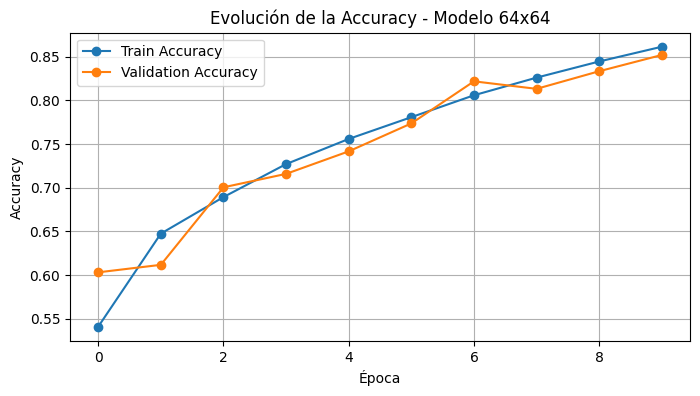

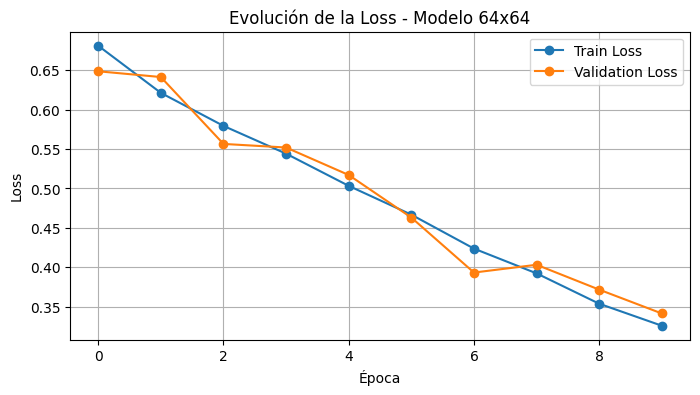

In [98]:
# Accuracy
plt.figure(figsize=(8, 4))
plt.plot(history_64.history["accuracy"], marker="o", label="Train Accuracy")
plt.plot(history_64.history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Evolución de la Accuracy - Modelo 64x64")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8, 4))
plt.plot(history_64.history["loss"], marker="o", label="Train Loss")
plt.plot(history_64.history["val_loss"], marker="o", label="Validation Loss")
plt.title("Evolución de la Loss - Modelo 64x64")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Conclusión:
### La reducción del tamaño de las imágenes a 64x64 permitió mejorar notablemente el rendimiento del modelo. A diferencia del experimento con 200x200, donde el modelo se mantuvo cerca del azar, en esta nueva configuración la CNN logró aprender patrones relevantes, alcanzando una accuracy de entrenamiento de 86.15% y una accuracy de validación de 85.20%. Además, el entrenamiento fue más rápido y computacionalmente más eficiente, lo que confirma que esta resolución intermedia fue una mejor elección para este problema.

# Probamos el modelo

In [101]:
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import load_img, img_to_array

class_names = {0: "cat", 1: "dog"}

# Cargar el mejor modelo guardado
best_model_64 = load_model("/content/best_model_64x64.keras")

def predict_image_with_true_label(model, img_path, true_label, img_size=(64, 64)):
    img = load_img(img_path, target_size=img_size)
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)
    predicted_class = np.argmax(pred, axis=1)[0]
    confidence = np.max(pred)

    plt.figure(figsize=(4, 4))
    plt.imshow(load_img(img_path))
    plt.title(
        f"Real: {class_names[true_label]} | Pred: {class_names[predicted_class]} ({confidence:.2%})"
    )
    plt.axis("off")
    plt.show()

    print("Ruta:", img_path)
    print("Etiqueta real:", class_names[true_label])
    print("Predicción:", class_names[predicted_class])
    print("Confianza:", f"{confidence:.4f}")
    print("Probabilidades:", pred)

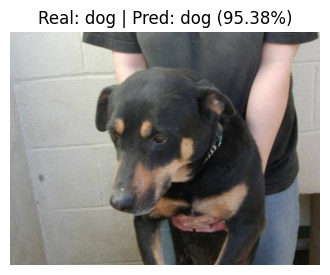

Ruta: /content/train/dog.1867.jpg
Etiqueta real: dog
Predicción: dog
Confianza: 0.9538
Probabilidades: [[0.0462188  0.95378125]]


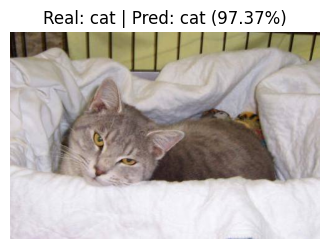

Ruta: /content/train/cat.2378.jpg
Etiqueta real: cat
Predicción: cat
Confianza: 0.9737
Probabilidades: [[0.9736708 0.0263292]]


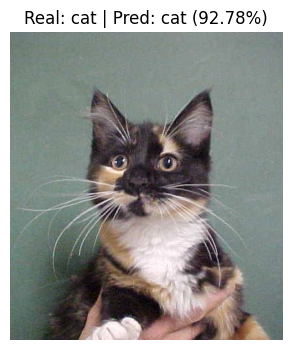

Ruta: /content/train/cat.2545.jpg
Etiqueta real: cat
Predicción: cat
Confianza: 0.9278
Probabilidades: [[0.9277723  0.07222767]]


In [102]:
for i in range(1, 4):
    sample_path = test_df["filepath"].iloc[i]
    sample_label = test_df["label"].iloc[i]
    predict_image_with_true_label(best_model_64, sample_path, sample_label, img_size=(64, 64))